In [9]:
import sys
from pathlib import Path

VALUATION_DIR = Path.cwd().parent
sys.path.insert(0, str(VALUATION_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold, cross_val_score, cross_val_predict, train_test_split
from sklearn.inspection import permutation_importance

from train_valuation import (
    load_dataset,
    apply_domain_filter,
    build_features,
    haversine_km,
    infer_property_type,
    build_model,
    available_model_kinds,
    select_model_kind_by_cv,
    tune_hyperparameters,
    CENTER_LAT,
    CENTER_LON,
    MAX_DISTANCE_KM,
    RANDOM_STATE,
    N_SPLITS,
)

sns.set_theme(style="whitegrid")

## 1. Tải và chuẩn bị dữ liệu (dùng lại đúng logic production)

In [10]:
df = load_dataset()

df["property_type"] = df["url"].apply(infer_property_type)

df["distance_km"] = haversine_km(
    pd.to_numeric(df["latitude"], errors="coerce"),
    pd.to_numeric(df["longitude"], errors="coerce"),
    CENTER_LAT,
    CENTER_LON,
)

bad_geo = df["distance_km"] > MAX_DISTANCE_KM
df.loc[bad_geo, ["latitude", "longitude", "distance_km"]] = np.nan

df = apply_domain_filter(df)

X = build_features(df)
y = np.log(df["price"].values)

print(f"So dong sau loc: {len(df)}")
X.head()

Loc nghiep vu: 1183 -> 1028 (loai 155)
So dong sau loc: 1028


,log_area,bedrooms,area_per_bedroom,distance_km,latitude,longitude,district,property_type
0,4.219508,2.0,34.00,6.378161,10.776856,106.75929,"(Phường Cát Lái, Hồ Chí Minh mới)",CAN_HO
1,3.637586,2.0,19.00,3.050664,10.750830,106.70960,"(Phường Tân Hưng, Hồ Chí Minh mới)",CAN_HO
2,4.094345,2.0,30.00,17.219899,10.840369,106.84471,"(Phường Long Bình, Hồ Chí Minh mới)",CAN_HO
3,4.302713,2.0,36.95,16.612849,10.838610,106.83942,"(Phường Long Bình, Hồ Chí Minh mới)",CAN_HO
4,4.787492,3.0,40.00,4.256668,10.738620,106.70060,"(Phường Tân Hưng, Hồ Chí Minh mới)",CAN_HO


## 2. Ma trận tương quan giữa các đặc trưng số và giá

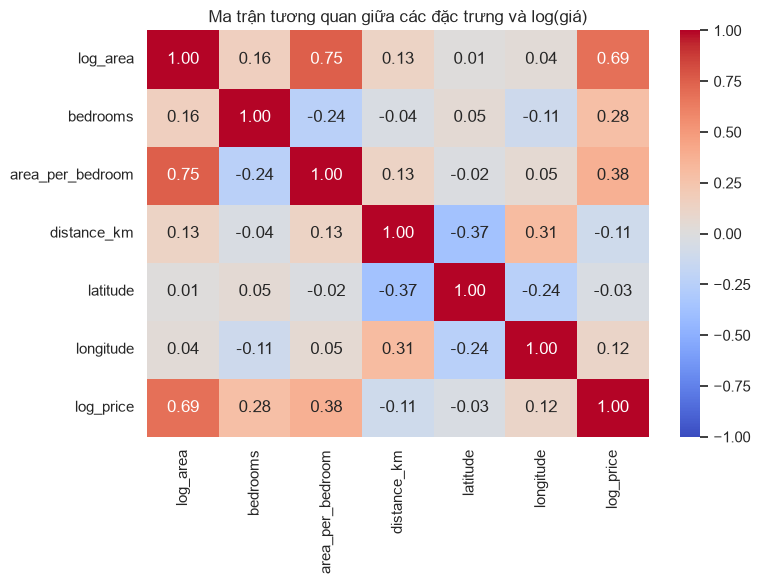

In [11]:
corr_df = X.copy()
corr_df["log_price"] = y

numeric_cols = ["log_area", "bedrooms", "area_per_bedroom", "distance_km", "latitude", "longitude", "log_price"]

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Ma trận tương quan giữa các đặc trưng và log(giá)")
plt.tight_layout()
plt.savefig("fig_correlation_heatmap.png", dpi=150)
plt.show()

## 3. So sánh CV R² giữa các loại mô hình (chỉ trên tập train)

,model,cv_r2_mean,cv_r2_std
0,catboost,0.789108,0.034584
1,lgbm,0.779774,0.033373
2,xgb,0.774030,0.034213
3,ridge,0.769870,0.031100
4,gbr,0.761660,0.051947
5,rf,0.756688,0.033011


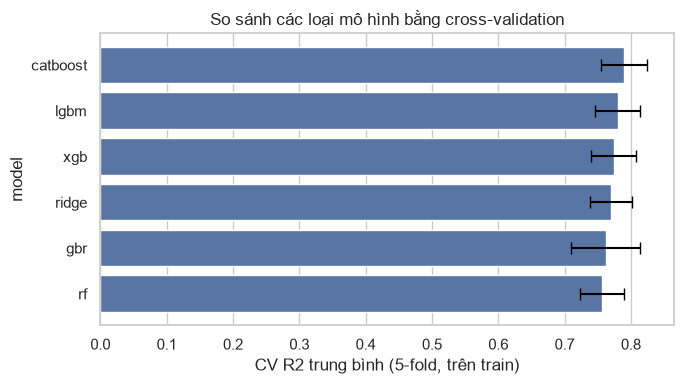

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

cv_records = []
for kind in available_model_kinds():
    scores = cross_val_score(build_model(kind), X_train, y_train, cv=kf, scoring="r2", n_jobs=-1)
    cv_records.append({"model": kind, "cv_r2_mean": scores.mean(), "cv_r2_std": scores.std()})

cv_df = pd.DataFrame(cv_records).sort_values("cv_r2_mean", ascending=False).reset_index(drop=True)
display(cv_df)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=cv_df, x="cv_r2_mean", y="model", ax=ax)
ax.errorbar(cv_df["cv_r2_mean"], range(len(cv_df)), xerr=cv_df["cv_r2_std"], fmt="none", c="black", capsize=4)
ax.set_xlabel("CV R2 trung bình (5-fold, trên train)")
ax.set_title("So sánh các loại mô hình bằng cross-validation")
plt.tight_layout()
plt.savefig("fig_cv_model_comparison.png", dpi=150)
plt.show()

## 4. Huấn luyện mô hình được chọn và so sánh giá thực tế vs dự đoán

CHON LOAI MO HINH BANG CROSS-VALIDATION (chi tren train)
  ridge     : CV R2 = 0.7699 (+/- 0.0311)
  rf        : CV R2 = 0.7567 (+/- 0.0330)
  gbr       : CV R2 = 0.7617 (+/- 0.0519)
  xgb       : CV R2 = 0.7740 (+/- 0.0342)
  lgbm      : CV R2 = 0.7798 (+/- 0.0334)
  catboost  : CV R2 = 0.7891 (+/- 0.0346)

Loai mo hinh tot nhat theo CV: catboost (R2 = 0.7891)

Tuning sieu tham so cho catboost (RandomizedSearchCV, 25 to hop)...
  Tham so tot nhat: {'model__learning_rate': 0.1, 'model__iterations': 400, 'model__depth': 6}
  CV R2 sau tuning: 0.7980


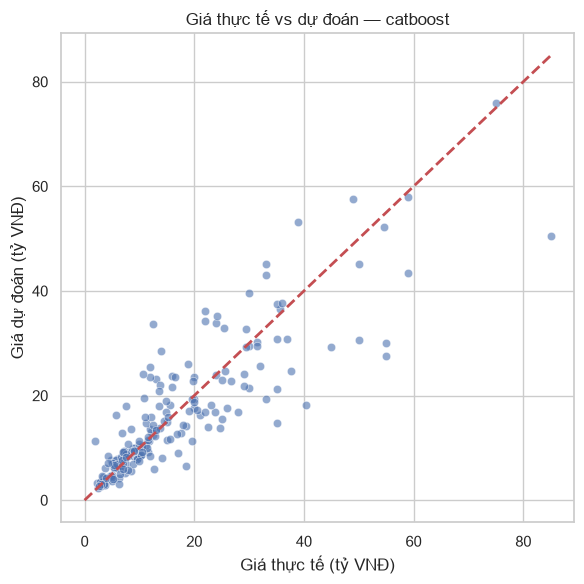

In [13]:
best_kind, cv_mean_selection, cv_std_selection = select_model_kind_by_cv(X_train, y_train)
tuned_model, best_params = tune_hyperparameters(best_kind, X_train, y_train)

y_pred_log = tuned_model.predict(X_test)

y_test_price = np.exp(y_test) / 1_000_000_000
y_pred_price = np.exp(y_pred_log) / 1_000_000_000

plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test_price, y=y_pred_price, alpha=0.6)
lims = [0, max(y_test_price.max(), y_pred_price.max())]
plt.plot(lims, lims, "r--", lw=2)
plt.xlabel("Giá thực tế (tỷ VNĐ)")
plt.ylabel("Giá dự đoán (tỷ VNĐ)")
plt.title(f"Giá thực tế vs dự đoán — {best_kind}")
plt.tight_layout()
plt.savefig("fig_actual_vs_predicted.png", dpi=150)
plt.show()

## 5. Diễn giải mô hình bằng Permutation Importance (model-agnostic)

,feature,importance_mean,importance_std
0,log_area,0.847919,0.072779
1,distance_km,0.155732,0.020939
2,property_type,0.135966,0.015852
3,district,0.109246,0.016508
4,longitude,0.041421,0.006501
5,bedrooms,0.032122,0.009630
6,latitude,0.021469,0.007714
7,area_per_bedroom,0.017657,0.008361


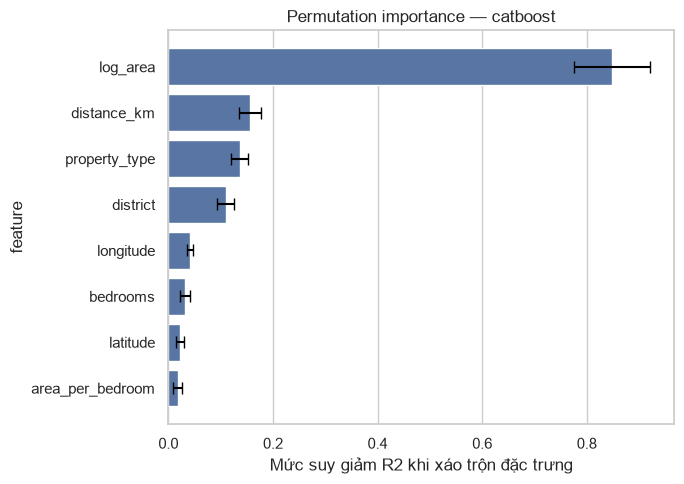

In [14]:
perm_result = permutation_importance(
    tuned_model, X_test, y_test, n_repeats=20, random_state=RANDOM_STATE, scoring="r2", n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std,
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

display(importance_df)

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=importance_df, x="importance_mean", y="feature", ax=ax)
ax.errorbar(importance_df["importance_mean"], range(len(importance_df)), xerr=importance_df["importance_std"], fmt="none", c="black", capsize=4)
ax.set_xlabel("Mức suy giảm R2 khi xáo trộn đặc trưng")
ax.set_title(f"Permutation importance — {best_kind}")
plt.tight_layout()
plt.savefig("fig_permutation_importance.png", dpi=150)
plt.show()

## 6. Phân phối residual out-of-fold (cơ sở tính sigma cho Mind Score)

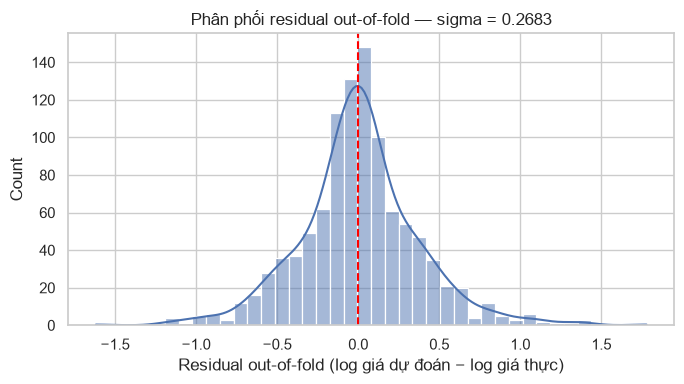

In [15]:
final_params = {k.replace("model__", ""): v for k, v in best_params.items()} if best_params else None

oof_pred = cross_val_predict(build_model(best_kind, final_params), X, y, cv=kf, n_jobs=-1)
oof_resid = oof_pred - y

q1, q3 = np.percentile(oof_resid, [25, 75])
sigma_oof = max(float((q3 - q1) / 1.349), 0.05)

plt.figure(figsize=(7, 4))
sns.histplot(oof_resid, bins=40, kde=True)
plt.axvline(0, color="red", linestyle="--")
plt.xlabel("Residual out-of-fold (log giá dự đoán − log giá thực)")
plt.title(f"Phân phối residual out-of-fold — sigma = {sigma_oof:.4f}")
plt.tight_layout()
plt.savefig("fig_oof_residual_distribution.png", dpi=150)
plt.show()